<a href="https://colab.research.google.com/github/LoYanYuet-Janice/Practical-Exam-2/blob/main/SEEM3650_Project_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Reading AQHI data...

Target Distribution:
 target
0    3234
1      55
Name: count, dtype: int64

Evaluating Models using custom 65.0% Risk Threshold...

--- Logistic Regression (Threshold >= 65%) ---
ROC-AUC: 0.8421
              precision    recall  f1-score   support

           0       0.99      0.72      0.83       639
           1       0.08      0.84      0.15        19

    accuracy                           0.72       658
   macro avg       0.54      0.78      0.49       658
weighted avg       0.97      0.72      0.81       658


--- Decision Tree (Threshold >= 65%) ---
ROC-AUC: 0.5401
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       639
           1       0.11      0.11      0.11        19

    accuracy                           0.95       658
   macro avg       0.54      0.54      0.54       658
weighted avg       0.95      0.95      0.95       658


--- Random Forest (Threshold >= 65%) ---
ROC-AUC: 0.8397
             

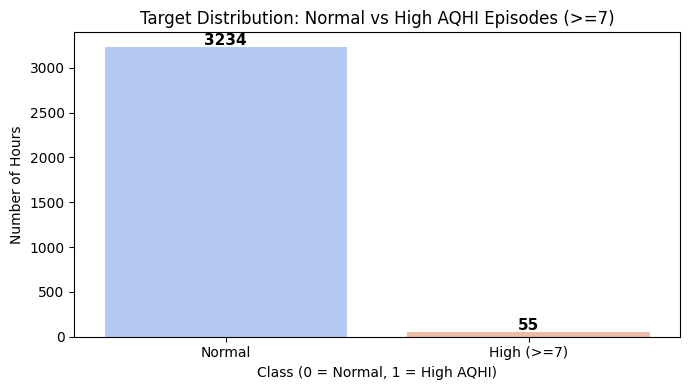

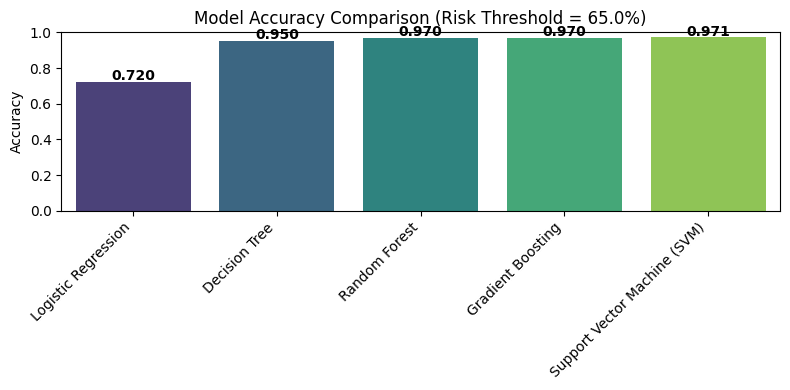

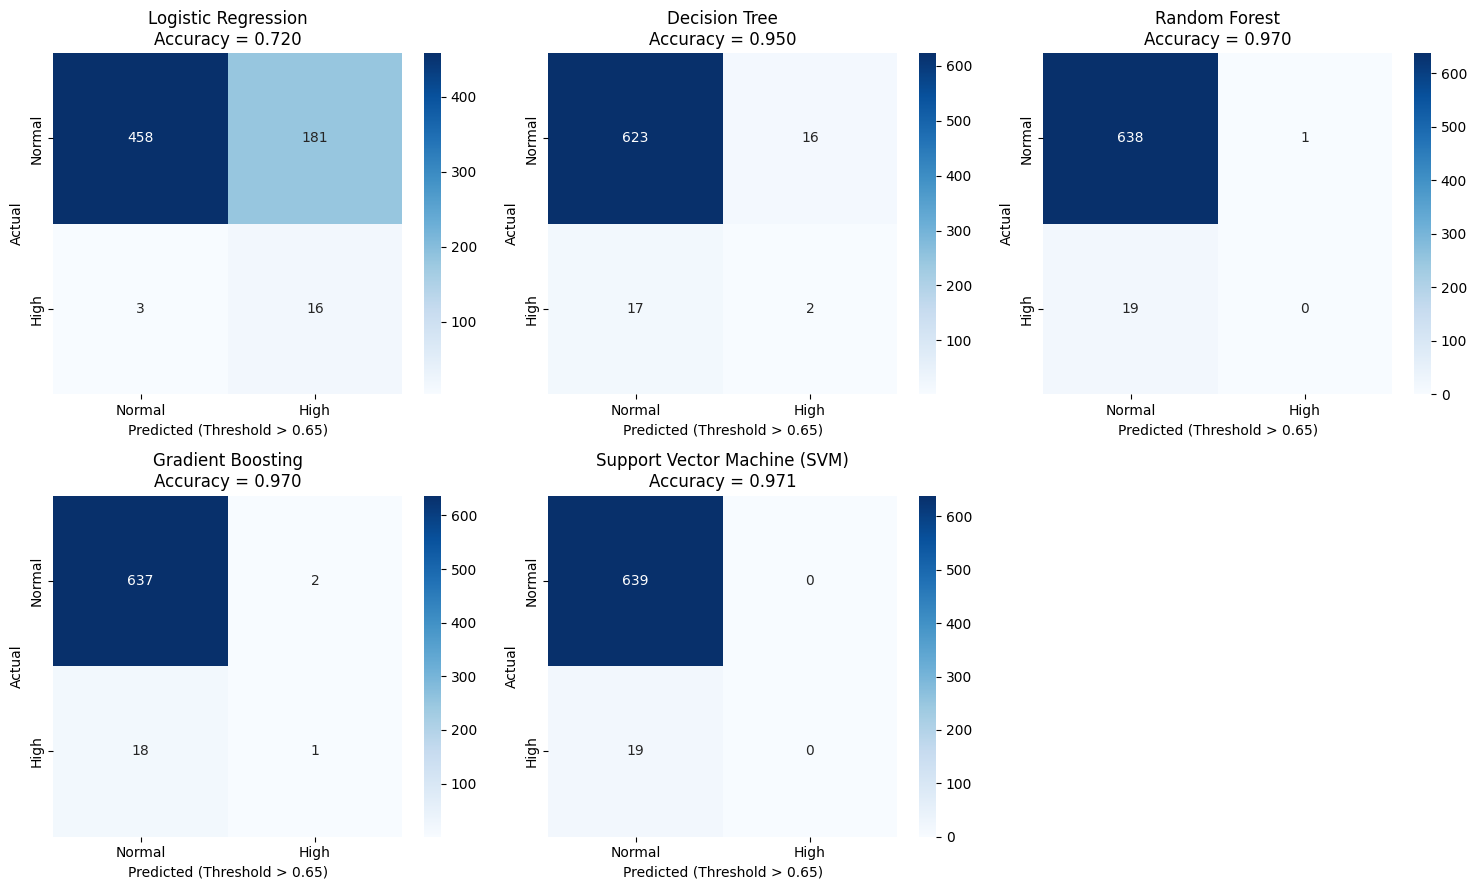

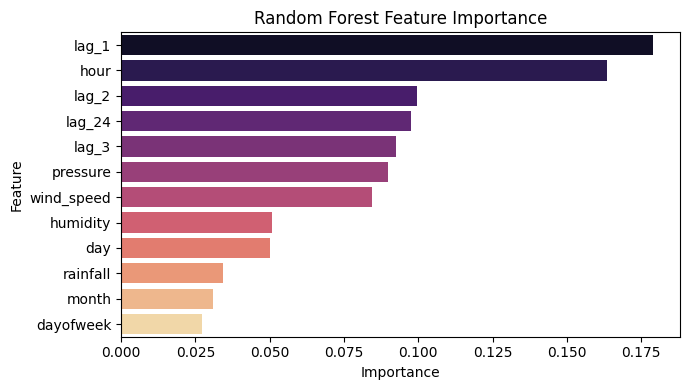

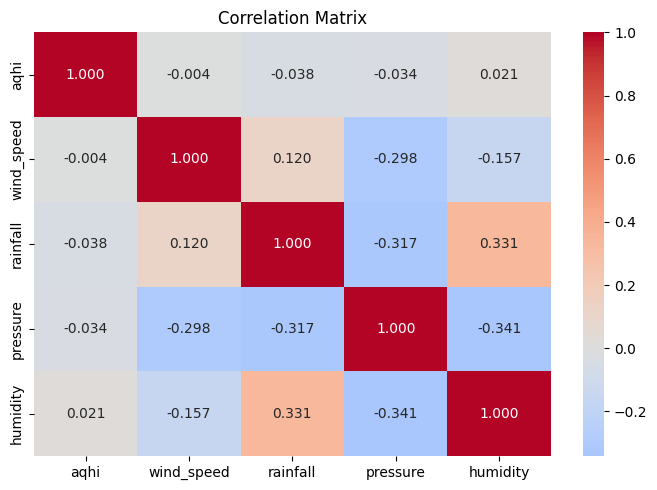

In [ ]:
"""
SEEM3650 Project: Predicting High AQHI Episodes
Dataset: 2024 Sha Tin
Feature: Implements the 65% Probability Threshold Warning System
"""

%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')

# 1. Load and Clean AQHI Data
print("Reading AQHI data...")
df_aqhi = pd.read_csv('202401-12_Eng.csv', skiprows=7)
df_aqhi = df_aqhi[pd.to_numeric(df_aqhi['Hour'], errors='coerce').notna()]
df_aqhi['Hour'] = df_aqhi['Hour'].astype(int)

# Fix missing date values
df_aqhi['Date'] = df_aqhi['Date'].ffill()

def clean_aqhi(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip()
    if s == '':
        return np.nan
    s = s.replace('*', '')
    if '+' in s:
        return float(s.replace('+', ''))
    try:
        return float(s)
    except ValueError:
        return np.nan

for col in df_aqhi.columns[2:]:
    df_aqhi[col] = df_aqhi[col].apply(clean_aqhi)

df_aqhi['Datetime'] = pd.to_datetime(
    df_aqhi['Date'] + ' ' + df_aqhi['Hour'].astype(str) + ':00',
    format='%d/%m/%Y %H:%M',
    errors='coerce'
)
df_aqhi.set_index('Datetime', inplace=True)
df_aqhi.drop(columns=['Date', 'Hour'], inplace=True)
df_aqhi.fillna(method='ffill', inplace=True)
df_aqhi.dropna(inplace=True)

target_station = 'Sha Tin'
data = df_aqhi[[target_station]].copy()
data.columns = ['aqhi']

# 2. Read Weather Datasets
def read_daily_file(filename, value_column_name):
    df = pd.read_csv(filename, skiprows=2, header=0, encoding='utf-8-sig')
    df.columns = ['Year', 'Month', 'Day', 'Value', 'Completeness']
    for col in ['Year', 'Month', 'Day']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df.dropna(subset=['Year', 'Month', 'Day'], inplace=True)

    df['Year'] = df['Year'].astype(int)
    df['Month'] = df['Month'].astype(int)
    df['Day'] = df['Day'].astype(int)

    df['Value'] = df['Value'].replace('***', np.nan)
    df['Value'] = pd.to_numeric(df['Value'], errors='coerce')
    df['Date'] = pd.to_datetime(df[['Year', 'Month', 'Day']], errors='coerce')
    df = df[df['Date'].dt.year == 2024]

    df = df[['Date', 'Value']].copy()
    df.rename(columns={'Value': value_column_name}, inplace=True)
    df.dropna(subset=[value_column_name], inplace=True)
    return df

df_wind  = read_daily_file('daily_SHA_WSPD_ALL.csv', 'wind_speed')
df_rain  = read_daily_file('daily_SHA_RF_ALL.csv', 'rainfall')
df_press = read_daily_file('daily_SHA_MSLP_ALL.csv', 'pressure')
df_humid = read_daily_file('daily_SHA_RH_ALL.csv', 'humidity')

# 3. Merge AQHI with Meteorological Data
data = data.reset_index()
data['date_temp'] = data['Datetime'].dt.normalize()

data = data.merge(df_wind, left_on='date_temp', right_on='Date', how='left').drop(columns=['Date'])
data = data.merge(df_rain, left_on='date_temp', right_on='Date', how='left').drop(columns=['Date'])
data = data.merge(df_press, left_on='date_temp', right_on='Date', how='left').drop(columns=['Date'])
data = data.merge(df_humid, left_on='date_temp', right_on='Date', how='left').drop(columns=['Date'])

data.drop(columns=['date_temp'], inplace=True)
data.set_index('Datetime', inplace=True)

data['wind_speed'].fillna(method='ffill', inplace=True)
data['rainfall'].fillna(0, inplace=True)
data['pressure'].fillna(method='ffill', inplace=True)
data['humidity'].fillna(method='ffill', inplace=True)
data.dropna(inplace=True)

# 4. Feature Engineering & Target Formulation
data['hour'] = data.index.hour
data['dayofweek'] = data.index.dayofweek
data['month'] = data.index.month
data['day'] = data.index.day

for lag in [1, 2, 3, 24]:
    data[f'lag_{lag}'] = data['aqhi'].shift(lag)

data.dropna(inplace=True)

# Target Variable: 1 if AQHI >= 7 in any of the next 3 hours, else 0
data['target'] = (
    (data['aqhi'].shift(-1) >= 7) |
    (data['aqhi'].shift(-2) >= 7) |
    (data['aqhi'].shift(-3) >= 7)
).astype(int)
data.dropna(subset=['target'], inplace=True)

print("\nTarget Distribution:\n", data['target'].value_counts())

feature_cols = [
    'hour', 'dayofweek', 'month', 'day',
    'lag_1', 'lag_2', 'lag_3', 'lag_24',
    'wind_speed', 'rainfall', 'pressure', 'humidity'
]

X = data[feature_cols]
y = data['target']

split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Train and Evaluate Models (Using 65% Risk Threshold)
# Note: probability=True added to SVC
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Support Vector Machine (SVM)': SVC(class_weight='balanced', kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)
}

results = {}
THRESHOLD = 0.65  # <--- 65% Probability Threshold implemented here

print(f"\nEvaluating Models using custom {THRESHOLD*100}% Risk Threshold...")

for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    # 1. Get probabilities instead of pure classes
    y_prob = model.predict_proba(X_test_scaled)[:, 1] # Probability of Class 1 (High AQHI)

    # 2. Apply the 65% threshold
    y_pred_custom = (y_prob >= THRESHOLD).astype(int)

    # 3. Calculate metrics including the new ROC-AUC
    acc = accuracy_score(y_test, y_pred_custom)
    roc = roc_auc_score(y_test, y_prob) #ROC-AUC

    results[name] = acc
    print(f"\n--- {name} (Threshold >= 65%) ---")
    print(f"ROC-AUC: {roc:.4f}")
    print(classification_report(y_test, y_pred_custom))


# 6. Direct In-Notebook Visualizations

# 1. Target Distribution Chart
plt.figure(figsize=(7, 4))
sns.countplot(x='target', data=data, palette='coolwarm')
plt.title('Target Distribution: Normal vs High AQHI Episodes (>=7)')
plt.xlabel('Class (0 = Normal, 1 = High AQHI)')
plt.ylabel('Number of Hours')
plt.xticks([0, 1], ['Normal', 'High (>=7)'])
counts = data['target'].value_counts()
for i, count in enumerate(counts):
    plt.text(i, count + 20, str(count), ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Accuracy Comparison
plt.figure(figsize=(8, 4))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')
plt.ylim(0, 1.0)
plt.title(f'Model Accuracy Comparison (Risk Threshold = {THRESHOLD*100}%)')
plt.ylabel('Accuracy')
plt.xticks(rotation=45, ha='right')
for i, acc in enumerate(results.values()):
    plt.text(i, acc + 0.01, f'{acc:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Confusion Matrix Plots (Using 65% threshold)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for idx, (name, model) in enumerate(models.items()):

    # Re-apply threshold for plotting
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    y_pred_custom = (y_prob >= THRESHOLD).astype(int)

    cm = confusion_matrix(y_test, y_pred_custom, labels=[0, 1])

    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Normal', 'High'],
        yticklabels=['Normal', 'High'],
        ax=axes[idx]
    )
    axes[idx].set_title(f'{name}\nAccuracy = {results[name]:.3f}')
    axes[idx].set_xlabel(f'Predicted (Threshold > {THRESHOLD})')
    axes[idx].set_ylabel('Actual')
if len(models) < len(axes):
    fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

# 4. Feature Importance (Random Forest)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
importances = rf.feature_importances_
feat_imp = pd.DataFrame({'Feature': feature_cols, 'Importance': importances}).sort_values('Importance', ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='magma')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

# 5. Correlation Matrix
plt.figure(figsize=(7, 5))
weather_features = ['aqhi', 'wind_speed', 'rainfall', 'pressure', 'humidity']
corr_matrix = data[weather_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()